In [16]:
#234567890#234567890#234567890#234567890#234567890#234567890#234567890#234567890
import ssl

from fastai.vision import all as fva
import fastbook as fb
import matplotlib.pyplot as plt


ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
VALID_FRAC = 0.2
SEED = 1492
fb.URLs.PETS

'https://s3.amazonaws.com/fast-ai-imageclas/oxford-iiit-pet.tgz'

In [3]:
path = fva.untar_data(fb.URLs.PETS)/'images'

In [4]:
def is_cat(x):
    return x[0].isupper()

In [5]:
dls = fva.ImageDataLoaders.from_name_func(
    path, 
    fva.get_image_files(path),
    valid_pct=VALID_FRAC,
    seed=SEED,
    label_func=is_cat,
    item_tfms=fva.Resize(224))

In [8]:
learn = fva.vision_learner(dls, fva.resnet34, metrics=fva.error_rate)
learn.remove_cb(fva.ProgressCallback)
learn.fine_tune(1)

[0, 0.13568219542503357, 0.02865026146173477, 0.00811908021569252, '02:03']
[0, 0.059286341071128845, 0.012093606404960155, 0.0033829498570412397, '02:44']


Fields for above are:

epoch|train_loss|valid_loss|error_rate|time
-----|----------|----------|----------|----

In [24]:
img = fva.PILImage.create('../img/OIP-4000092395.jpg')
is_cat, _, probs = learn.predict(img)
print('Cat?', is_cat)
print('p(cat) =', round(probs[1].item(), 6))

Cat? True
p(cat) = 0.686286


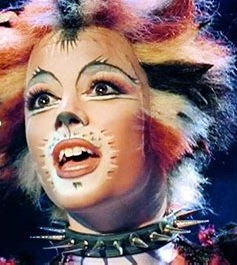

In [25]:
img